<a href="https://colab.research.google.com/github/vothanhly14/AI_Assignments_1/blob/main/AI_Assignments_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.1 MB/s eta 0:00:00


KẾT QUẢ MÔ PHỎNG CHO CUỐC XE GRAB-BIKE:
- Mức Giá cước (Thang 0-100): 91.35
- Mức Điểm thưởng (Thang 0-100): 86.60


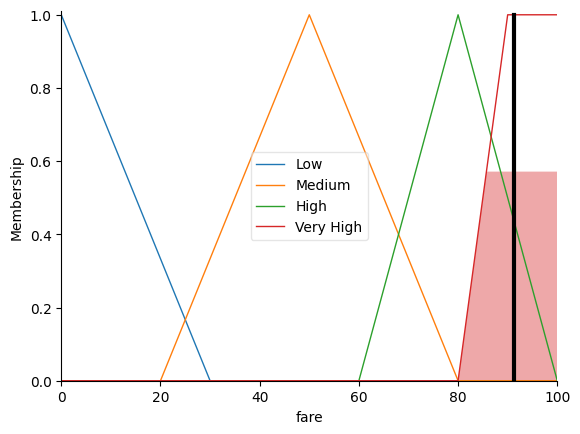

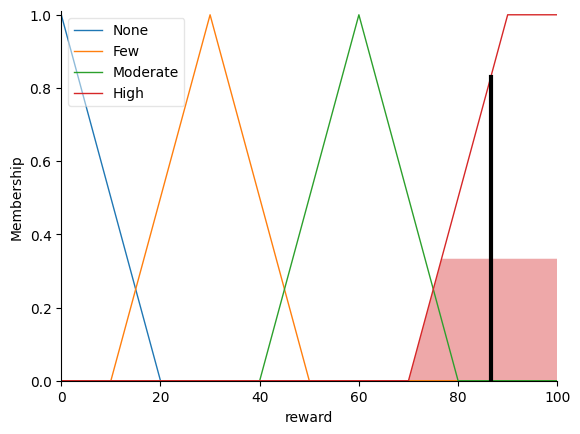

In [3]:
#2.11. TÌNH HUỐNG 1: HỆ THỐNG GIÁ TIỀN GRAB-BIKE
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# 1. Biến đầu vào
distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 101, 1), 'weather')
rating = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')

# 2. Biến đầu ra
fare = ctrl.Consequent(np.arange(0, 101, 1), 'fare')
reward = ctrl.Consequent(np.arange(0, 101, 1), 'reward')

# Khoảng cách
distance['Short'] = fuzz.trimf(distance.universe, [0, 0, 3])
distance['Medium'] = fuzz.trimf(distance.universe, [2, 5, 8])
distance['Long'] = fuzz.trimf(distance.universe, [6, 13, 20])
distance['Very Long'] = fuzz.trapmf(distance.universe, [15, 30, 50, 50])

# Tình trạng giao thông
traffic['Low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['Medium'] = fuzz.trimf(traffic.universe, [20, 45, 70])
traffic['High'] = fuzz.trapmf(traffic.universe, [60, 80, 100, 100])

# Mức cầu
demand['Low'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['Medium'] = fuzz.trimf(demand.universe, [20, 45, 70])
demand['High'] = fuzz.trapmf(demand.universe, [60, 80, 100, 100])

# Thời tiết
weather['Good'] = fuzz.trimf(weather.universe, [0, 0, 40])
weather['Moderate'] = fuzz.trimf(weather.universe, [30, 50, 70])
weather['Bad'] = fuzz.trapmf(weather.universe, [60, 80, 100, 100])

# Đánh giá khách hàng
rating['Poor'] = fuzz.trimf(rating.universe, [1.0, 1.0, 2.5])
rating['Average'] = fuzz.trimf(rating.universe, [2.0, 3.0, 4.0])
rating['Good'] = fuzz.trapmf(rating.universe, [3.5, 4.5, 5.0, 5.0])

# Đúng giờ
punctuality['Late'] = fuzz.trimf(punctuality.universe, [0, 0, 50])
punctuality['On Time'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['Early'] = fuzz.trapmf(punctuality.universe, [70, 85, 100, 100])

# Giá đi xe
fare['Low'] = fuzz.trimf(fare.universe, [0, 0, 30])
fare['Medium'] = fuzz.trimf(fare.universe, [20, 50, 80])
fare['High'] = fuzz.trimf(fare.universe, [60, 80, 100])
fare['Very High'] = fuzz.trapmf(fare.universe, [80, 90, 100, 100])

# Điểm thưởng
reward['None'] = fuzz.trimf(reward.universe, [0, 0, 20])
reward['Few'] = fuzz.trimf(reward.universe, [10, 30, 50])
reward['Moderate'] = fuzz.trimf(reward.universe, [40, 60, 80])
reward['High'] = fuzz.trapmf(reward.universe, [70, 90, 100, 100])

rules = [
    ctrl.Rule(distance['Short'] & traffic['Low'] & demand['Low'], fare['Low']),
    ctrl.Rule(distance['Short'] & traffic['Medium'] & demand['High'], fare['Medium']),
    ctrl.Rule(distance['Medium'] & traffic['High'] & demand['High'], fare['High']),
    ctrl.Rule(distance['Long'] & traffic['Medium'] & weather['Good'], fare['Medium']),
    ctrl.Rule(distance['Long'] & traffic['High'] & weather['Bad'], fare['Very High']),
    ctrl.Rule(distance['Very Long'] & traffic['High'] & demand['High'], fare['Very High']),
    ctrl.Rule(distance['Medium'] & traffic['Low'] & demand['Low'], fare['Medium']),
    ctrl.Rule(distance['Short'] & traffic['High'] & weather['Bad'], fare['High']),
    ctrl.Rule(distance['Very Long'] & weather['Bad'], fare['Very High']),
    ctrl.Rule(distance['Medium'] & traffic['Medium'] & weather['Moderate'], fare['Medium']),

    ctrl.Rule(rating['Good'] & punctuality['Early'], reward['High']),
    ctrl.Rule(rating['Average'] & punctuality['On Time'], reward['Moderate']),
    ctrl.Rule(rating['Poor'] & punctuality['Late'], reward['None']),
    ctrl.Rule(distance['Long'] & traffic['High'] & punctuality['On Time'], reward['High']),
    ctrl.Rule(distance['Medium'] & traffic['Medium'] & rating['Good'], reward['Moderate']),
    ctrl.Rule(rating['Poor'] & punctuality['Late'], reward['None']),
    ctrl.Rule(distance['Very Long'] & weather['Bad'] & rating['Good'], reward['High']),
    ctrl.Rule(distance['Short'] & rating['Average'] & punctuality['On Time'], reward['Few']),
    ctrl.Rule(distance['Long'] & traffic['High'] & punctuality['Late'], reward['Few']),
    ctrl.Rule(distance['Medium'] & weather['Moderate'] & rating['Good'], reward['Moderate'])
]

grab_ctrl = ctrl.ControlSystem(rules)
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)

grab_sim.input['distance'] = 10
grab_sim.input['traffic'] = 85
grab_sim.input['demand'] = 90
grab_sim.input['weather'] = 80
grab_sim.input['rating'] = 4.8
grab_sim.input['punctuality'] = 75

grab_sim.compute()

print("KẾT QUẢ MÔ PHỎNG CHO CUỐC XE GRAB-BIKE:")
print(f"- Mức Giá cước (Thang 0-100): {grab_sim.output['fare']:.2f}")
print(f"- Mức Điểm thưởng (Thang 0-100): {grab_sim.output['reward']:.2f}")

fare.view(sim=grab_sim)
reward.view(sim=grab_sim)

KẾT QUẢ ĐỀ XUẤT CHIẾT KHẤU SHOPEE
Mức chiết khấu tính toán được: 58.33%
=> Phân loại: RẤT CAO


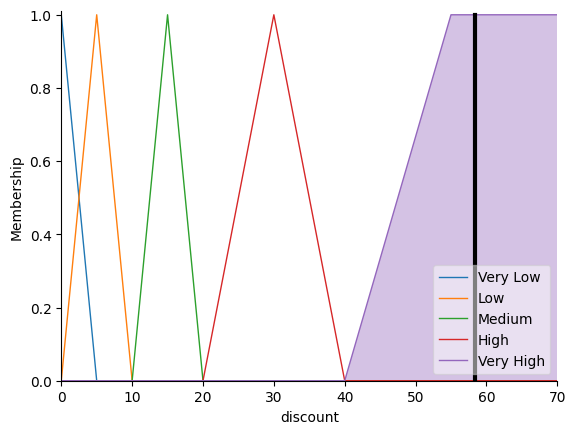

In [11]:
#2.12. TÌNH HUỐNG 2: CHIẾN LƯỢC CHIẾT KHẤU CHO KHÁCH HÀNG Ở CÁC CỬA HÀNG SHOPEE
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

rating = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'rating')
volume = ctrl.Antecedent(np.arange(0, 101, 1), 'volume')
margin = ctrl.Antecedent(np.arange(0, 101, 1), 'margin')
event = ctrl.Antecedent(np.arange(0, 101, 1), 'event')
competitor = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor')
discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

# Đánh giá cửa hàng
rating['Low'] = fuzz.trapmf(rating.universe, [1.0, 1.0, 3.5, 4.0])
rating['Medium'] = fuzz.trimf(rating.universe, [3.8, 4.25, 4.6])
rating['High'] = fuzz.trapmf(rating.universe, [4.4, 4.6, 5.0, 5.0])

# Khối lượng bán hàng
volume['Low'] = fuzz.trimf(volume.universe, [0, 0, 45])
volume['Medium'] = fuzz.trimf(volume.universe, [35, 50, 65])
volume['High'] = fuzz.trapmf(volume.universe, [55, 75, 100, 100])

# Biên lợi nhuận
margin['Low'] = fuzz.trimf(margin.universe, [0, 0, 30])
margin['Medium'] = fuzz.trimf(margin.universe, [20, 45, 70])
margin['High'] = fuzz.trapmf(margin.universe, [60, 80, 100, 100])

# Sự kiện theo mùa
event['None'] = fuzz.trimf(event.universe, [0, 0, 20])
event['Moderate'] = fuzz.trimf(event.universe, [10, 50, 80])
event['High'] = fuzz.trapmf(event.universe, [70, 90, 100, 100])

# Giảm giá cạnh tranh
competitor['Low'] = fuzz.trimf(competitor.universe, [0, 0, 40])
competitor['Medium'] = fuzz.trimf(competitor.universe, [30, 50, 70])
competitor['High'] = fuzz.trapmf(competitor.universe, [60, 80, 100, 100])

# Mức chiết khấu
discount['Very Low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['Low'] = fuzz.trimf(discount.universe, [0, 5, 10])
discount['Medium'] = fuzz.trimf(discount.universe, [10, 15, 20])
discount['High'] = fuzz.trimf(discount.universe, [20, 30, 40])
discount['Very High'] = fuzz.trapmf(discount.universe, [40, 55, 70, 70])

rules = [
    ctrl.Rule(rating['High'] & volume['High'] & margin['High'], discount['Very Low']),
    ctrl.Rule(rating['Low'] & volume['Low'] & margin['High'], discount['High']),
    ctrl.Rule(event['High'] & competitor['High'], discount['Very High']),
    ctrl.Rule(rating['Medium'] & volume['Medium'] & margin['Medium'], discount['Medium']),
    ctrl.Rule(competitor['Low'] & margin['Low'] & volume['High'], discount['Very Low']),
    ctrl.Rule(rating['Low'] & event['None'], discount['Medium']),
    ctrl.Rule(volume['Low'] & margin['Low'], discount['Very High'])
]

shopee_ctrl = ctrl.ControlSystem(rules)
shopee_sim = ctrl.ControlSystemSimulation(shopee_ctrl)

shopee_sim.input['rating'] = 4.3
shopee_sim.input['volume'] = 50
shopee_sim.input['margin'] = 15
shopee_sim.input['event'] = 95
shopee_sim.input['competitor'] = 90

shopee_sim.compute()

result_discount = shopee_sim.output['discount']
print("KẾT QUẢ ĐỀ XUẤT CHIẾT KHẤU SHOPEE")
print(f"Mức chiết khấu tính toán được: {result_discount:.2f}%")

if 20 <= result_discount <= 40:
    print("=> Phân loại: CAO (Khớp với đáp án kỳ vọng của đề bài!)")
elif result_discount > 40:
    print("=> Phân loại: RẤT CAO")
else:
    print("=> Phân loại: TRUNG BÌNH/THẤP")

discount.view(sim=shopee_sim)

KẾT QUẢ TƯ VẤN CHIẾT KHẤU MẶT HÀNG ĐẶC BIỆT
Mức chiết khấu tính toán bằng AI: 17.50%

=> HỆ THỐNG ĐÁNH GIÁ: Mức TRUNG BÌNH
=> Chiến lược: Duy trì biên lợi nhuận cao cho hàng xa xỉ dù đang mùa sale 11.11.


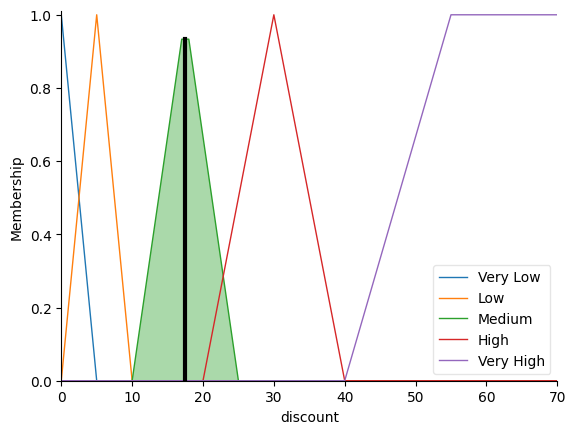

In [10]:
#2.13. TÌNH HUỐNG 3: KẾ HOẠCH CHIẾN LƯỢC BÁN HÀNG CỦA SHOPEE DÀNH CHO CÁC CỬA HÀNG
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'pressure')
reputation = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'reputation')
margin = ctrl.Antecedent(np.arange(0, 101, 1), 'margin')
season = ctrl.Antecedent(np.arange(0, 101, 1), 'season')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

# Nhu cầu sản phẩm
demand['Low'] = fuzz.trimf(demand.universe, [0, 0, 45])
demand['Medium'] = fuzz.trimf(demand.universe, [35, 50, 65])
demand['High'] = fuzz.trapmf(demand.universe, [55, 80, 100, 100])

# Áp lực định giá của đối thủ
pressure['Low'] = fuzz.trimf(pressure.universe, [0, 0, 40])
pressure['Medium'] = fuzz.trimf(pressure.universe, [30, 50, 70])
pressure['High'] = fuzz.trapmf(pressure.universe, [60, 80, 100, 100])

# Uy tín cửa hàng
reputation['Low'] = fuzz.trapmf(reputation.universe, [1.0, 1.0, 3.8, 4.0])
reputation['Medium'] = fuzz.trimf(reputation.universe, [3.9, 4.25, 4.6])
reputation['High'] = fuzz.trapmf(reputation.universe, [4.5, 4.7, 5.0, 5.0])

# Biên lợi nhuận
margin['Low'] = fuzz.trimf(margin.universe, [0, 0, 30])
margin['Medium'] = fuzz.trimf(margin.universe, [20, 50, 70])
margin['High'] = fuzz.trapmf(margin.universe, [60, 80, 100, 100])

# Nhu cầu theo mùa
season['None'] = fuzz.trimf(season.universe, [0, 0, 30])
season['Medium'] = fuzz.trimf(season.universe, [20, 50, 80])
season['High'] = fuzz.trapmf(season.universe, [70, 90, 100, 100])

# Mức giảm giá
discount['Very Low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['Low'] = fuzz.trimf(discount.universe, [0, 5, 10])
discount['Medium'] = fuzz.trimf(discount.universe, [10, 17.5, 25])
discount['High'] = fuzz.trimf(discount.universe, [20, 30, 40])
discount['Very High'] = fuzz.trapmf(discount.universe, [40, 55, 70, 70])

rules = [
    ctrl.Rule(demand['High'] & pressure['Low'] & margin['Low'], discount['Very Low']),
    ctrl.Rule(demand['Low'] & pressure['High'] & margin['High'], discount['High']),
    ctrl.Rule(reputation['High'] & margin['Medium'] & season['High'], discount['Medium']),
    ctrl.Rule(pressure['High'] & season['High'] & margin['High'], discount['Very High']),
    ctrl.Rule(reputation['Low'] & demand['Medium'] & margin['Low'], discount['Medium']),
    ctrl.Rule(demand['High'] & season['None'] & pressure['Low'], discount['Very Low']),
    ctrl.Rule(margin['High'] & pressure['Medium'] & season['Medium'], discount['Medium']),
    ctrl.Rule(margin['High'] & season['High'] & pressure['Medium'], discount['Medium'])
]

special_ctrl = ctrl.ControlSystem(rules)
special_sim = ctrl.ControlSystemSimulation(special_ctrl)

special_sim.input['demand'] = 85
special_sim.input['pressure'] = 50
special_sim.input['reputation'] = 4.2
special_sim.input['margin'] = 80
special_sim.input['season'] = 95

special_sim.compute()

result = special_sim.output['discount']
print("KẾT QUẢ TƯ VẤN CHIẾT KHẤU MẶT HÀNG ĐẶC BIỆT")
print(f"Mức chiết khấu tính toán bằng AI: {result:.2f}%\n")

if 10 <= result <= 25:
    print("=> HỆ THỐNG ĐÁNH GIÁ: Mức TRUNG BÌNH")
    print("=> Chiến lược: Duy trì biên lợi nhuận cao cho hàng xa xỉ dù đang mùa sale 11.11.")
else:
    print("=> HỆ THỐNG ĐÁNH GIÁ: Nằm ngoài mức Trung bình.")

discount.view(sim=special_sim)

KẾT QUẢ TỐI ƯU HÓA GIAO HÀNG
1. Số lượng đơn hàng nên kết hợp: 8 đơn hàng
2. Điểm ưu tiên giao hàng: 50.0 / 100
=> HỆ THỐNG ĐỀ XUẤT: Kết hợp NHIỀU đơn hàng.
=> HỆ THỐNG ĐỀ XUẤT: Mức độ ưu tiên TRUNG BÌNH.


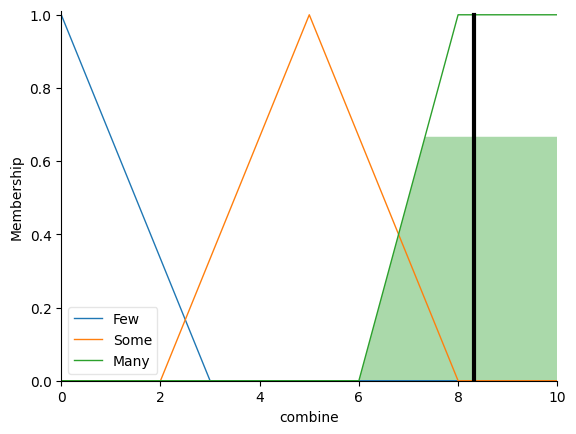

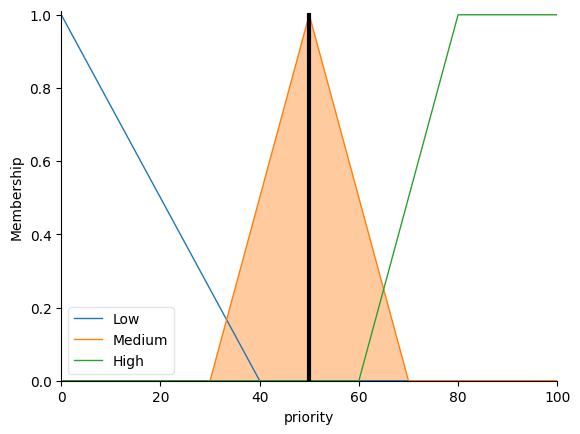

In [9]:
#2.14. TÌNH HUỐNG 4: TỐI ƯU HÓA THỜI GIAN GIAO HÀNG VÀ TĂNG THU NHẬP CHO TÀI XẾ
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

density = ctrl.Antecedent(np.arange(0, 101, 1), 'density')
urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'urgency')
load = ctrl.Antecedent(np.arange(0, 101, 1), 'load')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'profit')

combine = ctrl.Consequent(np.arange(0, 11, 1), 'combine')
priority = ctrl.Consequent(np.arange(0, 101, 1), 'priority')


# Dùng vòng lặp thiết lập tập mờ Thấp/Trung bình/Cao chung cho 5 biến đầu vào
for var in [density, urgency, load, traffic, profit]:
    var['Low'] = fuzz.trimf(var.universe, [0, 0, 45])
    var['Medium'] = fuzz.trimf(var.universe, [30, 50, 70])
    var['High'] = fuzz.trapmf(var.universe, [60, 80, 100, 100])

combine['Few'] = fuzz.trimf(combine.universe, [0, 0, 3])
combine['Some'] = fuzz.trimf(combine.universe, [2, 5, 8])
combine['Many'] = fuzz.trapmf(combine.universe, [6, 8, 10, 10])

priority['Low'] = fuzz.trimf(priority.universe, [0, 0, 40])
priority['Medium'] = fuzz.trimf(priority.universe, [30, 50, 70])
priority['High'] = fuzz.trapmf(priority.universe, [60, 80, 100, 100])


rules = [
    ctrl.Rule(density['High'] & load['Low'] & traffic['Low'], combine['Many']),
    ctrl.Rule(density['Medium'] & traffic['High'] & urgency['Medium'], combine['Few']),
    ctrl.Rule(load['High'] & density['High'] & profit['Medium'], combine['Some']),
    ctrl.Rule(density['Low'] & urgency['High'] & traffic['Medium'], combine['Few']),
    ctrl.Rule(profit['High'] & urgency['High'] & traffic['High'], combine['Few']),
    ctrl.Rule(density['High'] & load['Low'], combine['Many']),

    ctrl.Rule(urgency['High'] & profit['High'], priority['High']),
    ctrl.Rule(urgency['Medium'] & traffic['Medium'], priority['Medium']),
    ctrl.Rule(urgency['Low'] & density['High'] & profit['Low'], priority['Low'])
]

delivery_ctrl = ctrl.ControlSystem(rules)
delivery_sim = ctrl.ControlSystemSimulation(delivery_ctrl)

delivery_sim.input['density'] = 85
delivery_sim.input['urgency'] = 50
delivery_sim.input['load'] = 15
delivery_sim.input['traffic'] = 50
delivery_sim.input['profit'] = 50

delivery_sim.compute()

result_combine = delivery_sim.output['combine']
result_priority = delivery_sim.output['priority']

print("KẾT QUẢ TỐI ƯU HÓA GIAO HÀNG")
print(f"1. Số lượng đơn hàng nên kết hợp: {result_combine:.0f} đơn hàng")
print(f"2. Điểm ưu tiên giao hàng: {result_priority:.1f} / 100")

if result_combine >= 5:
    print("=> HỆ THỐNG ĐỀ XUẤT: Kết hợp NHIỀU đơn hàng.")
if 30 <= result_priority <= 70:
    print("=> HỆ THỐNG ĐỀ XUẤT: Mức độ ưu tiên TRUNG BÌNH.")

combine.view(sim=delivery_sim)
priority.view(sim=delivery_sim)